# Red neuronal multicapa desde cero · Tema 2 · Sesión 3

**Máster en Ingeniería de Automatización con IA Agéntica · EBIS**
Autor: Manuel Díaz Bendito

En la sesión anterior entrenamos una **neurona** para distinguir dos dígitos. Aquí damos el siguiente paso natural: una **red multicapa (Perceptrón Multicapa, MLP)** capaz de clasificar **los 10 dígitos de MNIST a la vez**.

Veremos dos ideas nuevas imprescindibles para problemas multiclase: la activación **softmax** (convierte las salidas en una distribución de probabilidad sobre las clases) y la **entropía cruzada categórica** como función de pérdida. Construimos el modelo en **PyTorch** y escribimos el bucle de entrenamiento por lotes a mano.

## 0 · Compatibilidad de hardware (léeme primero)

Este notebook funciona en **cualquier ordenador**. El código detecta automáticamente el mejor dispositivo de cómputo disponible y se adapta a él:

- **CUDA** → GPU NVIDIA (Windows / Linux). El más rápido para entrenar.
- **MPS** → GPUs de Apple Silicon (M1/M2/M3/M4). Acelera mucho en Mac.
- **CPU** → cualquier máquina. Funciona siempre; más lento, pero perfectamente válido para los modelos de este notebook.

No tienes que cambiar nada manualmente: la celda de detección de dispositivo elige sola. Si entrenas en CPU, los tiempos de este notebook siguen siendo de pocos minutos.

## 1 · Instalación e importación de librerías

In [1]:
# Ejecuta una sola vez si te falta alguna librería:
%pip install torch torchvision numpy matplotlib scikit-learn

  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 35.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 31.5 MB/s  0:0

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)
print("PyTorch:", torch.__version__)

PyTorch: 2.12.0


## 2 · Detección automática de dispositivo

In [2]:
def elegir_dispositivo():
    """Devuelve el mejor dispositivo disponible: CUDA > MPS > CPU."""
    if torch.cuda.is_available():
        print(f"✅ Usando CUDA (GPU NVIDIA): {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        print("✅ Usando MPS (Apple Silicon)")
        return torch.device("mps")
    print("⚠️  No se ha detectado GPU. Usando CPU (funciona igual, algo más lento).")
    return torch.device("cpu")

device = elegir_dispositivo()
print("Dispositivo seleccionado:", device)

✅ Usando MPS (Apple Silicon)
Dispositivo seleccionado: mps


## 3 · De una neurona a una red de clasificación multiclase

Para distinguir **10 clases** en lugar de 2, la red termina en **10 neuronas de salida**, una por dígito. Cada una produce un número (*logit*); la función **softmax** los convierte en probabilidades que suman 1:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

El modelo predice la clase con mayor probabilidad. El error se mide con la **entropía cruzada categórica**, que penaliza asignar poca probabilidad a la clase correcta. En PyTorch, `nn.CrossEntropyLoss` aplica softmax + entropía cruzada de forma estable, así que la red devuelve directamente los logits.

Nuestra arquitectura: `784 → 256 (ReLU) → 128 (ReLU) → 10`. Dos capas ocultas permiten aprender combinaciones no lineales de los píxeles.

## 4 · Cargamos MNIST completo (10 clases)

In [3]:
transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="./datos", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./datos", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)} | Clases: 10 (dígitos 0-9)")

100.0%
100.0%
100.0%
100.0%

Train: 60000 | Test: 10000 | Clases: 10 (dígitos 0-9)


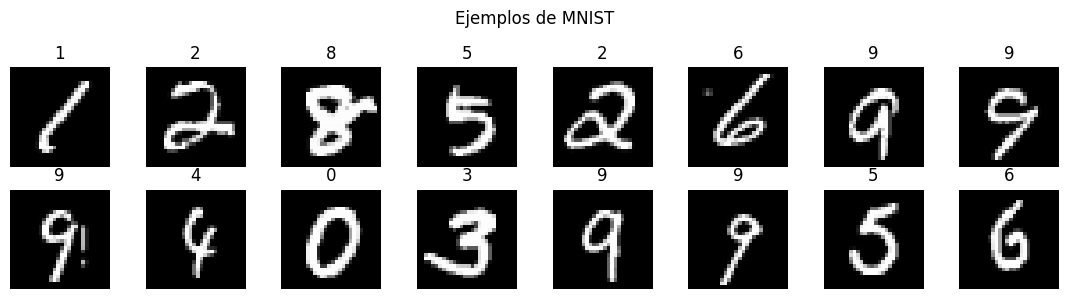

In [4]:
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, lab in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.squeeze().numpy(), cmap="gray"); ax.set_title(f"{int(lab)}"); ax.axis("off")
plt.suptitle("Ejemplos de MNIST"); plt.tight_layout(); plt.show()

## 5 · Definimos el MLP

`nn.Flatten` aplana cada imagen 28×28 en un vector de 784 dentro del propio modelo, así el `DataLoader` puede servir las imágenes tal cual.

In [5]:
class MLP(nn.Module):
    def __init__(self, n_clases=10):
        super().__init__()
        self.red = nn.Sequential(
            nn.Flatten(),              # (B,1,28,28) -> (B,784)
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n_clases),  # 10 logits
        )
    def forward(self, x):
        return self.red(x)

modelo = MLP().to(device)
n_params = sum(p.numel() for p in modelo.parameters())
print(modelo)
print(f"\nParámetros entrenables: {n_params:,}")

MLP(
  (red): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parámetros entrenables: 235,146


## 6 · Entrenamiento por lotes

El mismo bucle de 4 fases de la sesión anterior, ahora recorriendo el dataset en lotes y varias épocas.

In [6]:
def evaluar(modelo, loader):
    modelo.eval()
    correctos = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correctos += (modelo(x).argmax(1) == y).sum().item()
            total += y.size(0)
    return correctos / total

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
n_epocas = 5

hist_loss, hist_acc = [], []
for epoca in range(n_epocas):
    modelo.train(); perdida = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = criterio(modelo(x), y)
        optimizador.zero_grad(); loss.backward(); optimizador.step()
        perdida += loss.item()
    acc = evaluar(modelo, test_loader)
    hist_loss.append(perdida/len(train_loader)); hist_acc.append(acc)
    print(f"Época {epoca+1}/{n_epocas} | loss {hist_loss[-1]:.4f} | accuracy test {acc*100:.2f} %")

Época 1/5 | loss 0.3488 | accuracy test 94.56 %
Época 2/5 | loss 0.1351 | accuracy test 96.49 %
Época 3/5 | loss 0.0899 | accuracy test 97.18 %
Época 4/5 | loss 0.0657 | accuracy test 97.34 %
Época 5/5 | loss 0.0501 | accuracy test 97.62 %


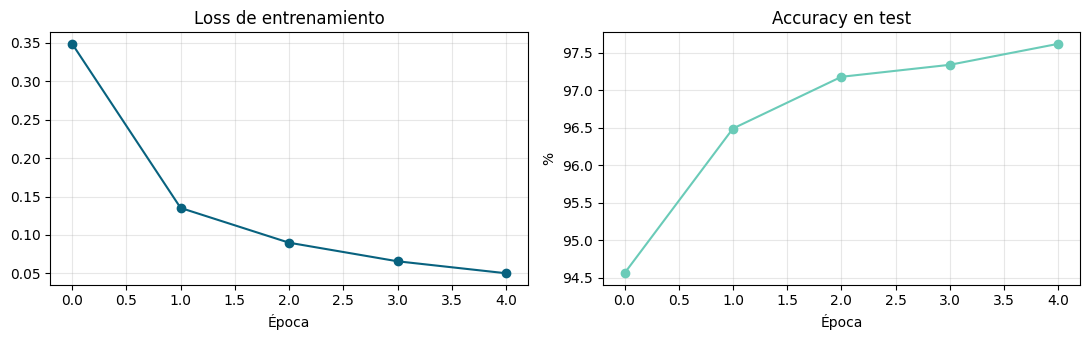

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.plot(hist_loss, marker="o", color="#08627F"); a1.set_title("Loss de entrenamiento")
a1.set_xlabel("Época"); a1.grid(alpha=0.3)
a2.plot([a*100 for a in hist_acc], marker="o", color="#6ACBB8"); a2.set_title("Accuracy en test")
a2.set_xlabel("Época"); a2.set_ylabel("%"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7 · Evaluación y matriz de confusión

Accuracy test: 97.62 %

              precision    recall  f1-score   support

           0      0.971     0.992     0.981       980
           1      0.993     0.989     0.991      1135
           2      0.982     0.965     0.974      1032
           3      0.981     0.970     0.976      1010
           4      0.959     0.982     0.970       982
           5      0.959     0.987     0.972       892
           6      0.988     0.961     0.975       958
           7      0.974     0.982     0.978      1028
           8      0.975     0.962     0.968       974
           9      0.977     0.970     0.974      1009

    accuracy                          0.976     10000
   macro avg      0.976     0.976     0.976     10000
weighted avg      0.976     0.976     0.976     10000



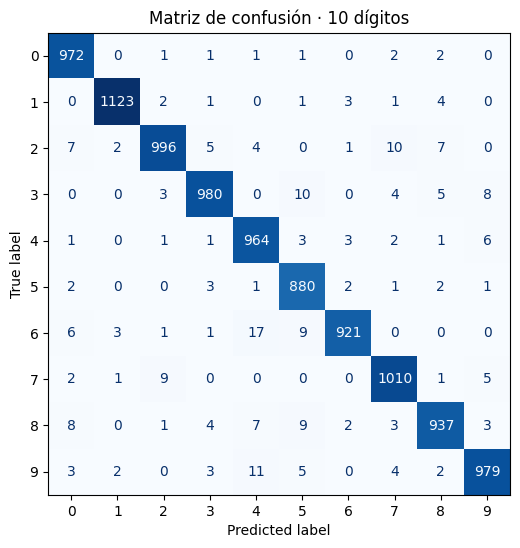

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

modelo.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        y_pred.extend(modelo(x.to(device)).argmax(1).cpu().tolist()); y_true.extend(y.tolist())

print(f"Accuracy test: {np.mean(np.array(y_true)==np.array(y_pred))*100:.2f} %\n")
print(classification_report(y_true, y_pred, digits=3))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Matriz de confusión · 10 dígitos"); plt.show()

## 8 · ¿Dónde se equivoca? · ejemplos mal clasificados

Los errores de un MLP sobre MNIST son instructivos: suelen ser dígitos ambiguos incluso para una persona. Esto motiva el salto a las **redes convolucionales**, que aprovechan la estructura espacial y reducen estos errores.

In [14]:
imgs, labels = next(iter(test_loader))
with torch.no_grad():
    preds = modelo(imgs.to(device)).argmax(1).cpu()
fallos = (preds != labels).nonzero(as_tuple=True)[0][:12]

if len(fallos) == 0:
    print("No hay fallos en este lote. Ejecuta de nuevo para ver otros ejemplos.")
else:
    fig, axes = plt.subplots(2, 6, figsize=(11, 4))
    for ax, i in zip(axes.flatten(), fallos):
        ax.imshow(imgs[i].squeeze().numpy(), cmap="gray")
        ax.set_title(f"real {int(labels[i])} / pred {int(preds[i])}", color="red", fontsize=9)
        ax.axis("off")
    for ax in axes.flatten()[len(fallos):]:
        ax.axis("off")
    plt.suptitle("Ejemplos mal clasificados por el MLP"); plt.tight_layout(); plt.show()

No hay fallos en este lote. Ejecuta de nuevo para ver otros ejemplos.


## 9 · Lo que has aprendido

- Para clasificación **multiclase** la red termina en tantas neuronas como clases, con **softmax** + **entropía cruzada**.
- Un **MLP** de dos capas ocultas alcanza ~97-98 % en MNIST tratando la imagen como un vector plano.
- Sus errores típicos (dígitos deformados o ambiguos) motivan las **CNN**, que explotan la vecindad de los píxeles.

> En los siguientes notebooks de esta sesión construimos CNN: primero sobre MNIST y luego sobre imágenes en color (CIFAR-10).